<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/AULA_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install kagglehub tensorflow scikit-learn matplotlib pandas pillow opencv-python --quiet

In [22]:
import kagglehub
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [23]:
# --- BAIXAR DATASET ---
path = kagglehub.dataset_download("mariotormo/complete-pokemon-dataset-updated-090420/versions/5")
print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: /root/.cache/kagglehub/datasets/mariotormo/complete-pokemon-dataset-updated-090420/versions/5
['pokedex_(Update_05.20).csv', 'pokedex_(Update.04.20).csv']


In [24]:
# --- CARREGAR CSV ---
csv_path = os.path.join(path, "pokedex_(Update.04.20).csv")
data = pd.read_csv(csv_path)
print(data.head())

   Unnamed: 0  pokedex_number           name german_name        japanese_name  \
0           0               1      Bulbasaur     Bisasam  フシギダネ (Fushigidane)   
1           1               2        Ivysaur   Bisaknosp   フシギソウ (Fushigisou)   
2           2               3       Venusaur    Bisaflor  フシギバナ (Fushigibana)   
3           3               3  Mega Venusaur    Bisaflor  フシギバナ (Fushigibana)   
4           4               4     Charmander    Glumanda      ヒトカゲ (Hitokage)   

   generation  is_sub_legendary  is_legendary  is_mythical         species  \
0           1                 0             0            0    Seed Pokémon   
1           1                 0             0            0    Seed Pokémon   
2           1                 0             0            0    Seed Pokémon   
3           1                 0             0            0    Seed Pokémon   
4           1                 0             0            0  Lizard Pokémon   

   ...  against_ground against_flying agains

In [25]:
# --- PREPARAR OS DADOS ---
# Vamos usar apenas algumas colunas numéricas para treino de exemplo
numeric_data = data.select_dtypes(include=[np.number]).fillna(0)


In [27]:
# Definindo uma tarefa binária fictícia: Pokémon lendário (Legendary) ou não
y = data["is_legendary"].astype(int)
X = numeric_data

In [28]:
# Dividir os dados
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
# Normalização
X_train = np.array(X_train) / np.max(X_train)
X_test = np.array(X_test) / np.max(X_test)

In [32]:
# --- CONSTRUIR O MODELO ---
model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# --- TREINAR O MODELO ---
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8,
    validation_split=0.2
)


Epoch 1/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9742 - loss: 0.4707 - val_accuracy: 0.9515 - val_loss: 0.2291
Epoch 2/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9796 - loss: 0.1264 - val_accuracy: 0.9515 - val_loss: 0.2043
Epoch 3/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9662 - loss: 0.1649 - val_accuracy: 0.9515 - val_loss: 0.1830
Epoch 4/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9621 - loss: 0.1603 - val_accuracy: 0.9515 - val_loss: 0.1442
Epoch 5/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9605 - loss: 0.1305 - val_accuracy: 0.9515 - val_loss: 0.1231
Epoch 6/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9746 - loss: 0.0803 - val_accuracy: 0.9515 - val_loss: 0.0950
Epoch 7/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9723 - loss: 0.0932 - val_accuracy: 0.9576 - val_loss: 0.0812
Epoch 8/20
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9720 - loss: 0.0687 - val_accuracy: 0.9818 - val_loss

In [34]:
# --- AVALIAR O MODELO ---
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9856 - loss: 0.0546 
Test Loss: 0.0437
Test Accuracy: 0.9903


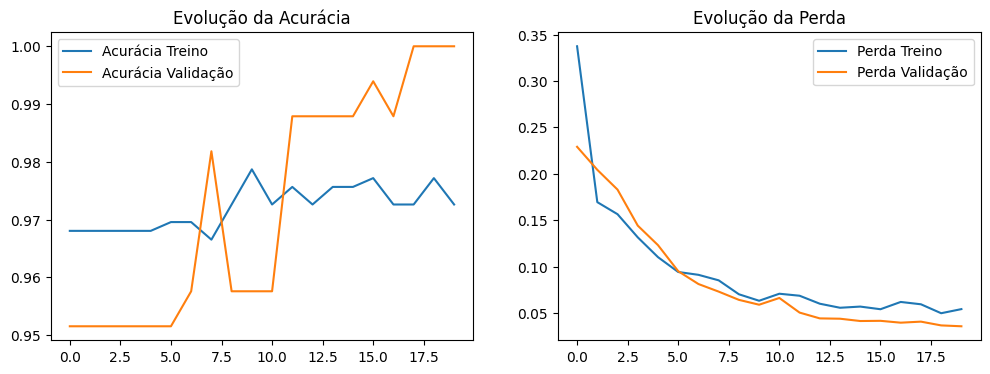

In [35]:
# --- PLOTAR RESULTADOS ---
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Acurácia Treino")
plt.plot(history.history["val_accuracy"], label="Acurácia Validação")
plt.title("Evolução da Acurácia")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Perda Treino")
plt.plot(history.history["val_loss"], label="Perda Validação")
plt.title("Evolução da Perda")
plt.legend()

plt.show()